# UMAP LGBM Experiment

This notebook tests whether `UMAP` components can replace the sparse anonymous feature set before training `LightGBM`.

`UMAP` is a non-linear dimensionality reduction method. Unlike PCA/SVD, it tries to preserve local neighborhood structure. That can be useful when predictive signal is non-linear, but it can also be slower and less stable, so this notebook keeps the setup intentionally simple.

## Learning Goals

- Fit sparse filtering, scaling, and UMAP inside each CV fold to avoid leakage.
- Compare a few UMAP component counts by CV RMSLE.
- Train LightGBM on UMAP components only.
- Compare the result with PCA-only and SVD-only notebooks.

In [1]:
# Add the project root to Python path so notebook imports can see the local src package.
import sys

sys.path.append("../")

# NumPy is used for log-transforming the target, inverse transforms, and CV aggregation.
import numpy as np
# Pandas is used for tabular data manipulation and readable result tables.
import pandas as pd
# Matplotlib is used for the 2D UMAP visualization subexperiment.
import matplotlib.pyplot as plt
# SciPy sparse matrices keep the mostly-zero feature matrix memory-efficient before UMAP.
from scipy import sparse

import umap

# StandardScaler with_mean=False scales sparse data without destroying sparsity.
from sklearn.preprocessing import StandardScaler
# Train/test split gives one held-out sanity-check set; KFold is used for component selection.
from sklearn.model_selection import KFold, train_test_split
# Metrics are calculated on original target scale after inverse log transform.
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, root_mean_squared_log_error

from src.loader import Loader
from src.metrics import format_metric_value
from src.modeling import build_lgbm_regressor
from src.preprocessing import FeaturePreprocessor

/Users/ayeustsihneyeu/ml_/santander/.santander/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

UMAP can be much slower than PCA or TruncatedSVD, so this first experiment keeps only a small component grid. The model parameters are fixed on purpose: the notebook measures the UMAP representation, not another LightGBM tuning run.

`SPARSITY_THRESHOLD=0.9875` follows the best sparse-filtering experiment. The threshold is fitted inside every fold, so validation rows do not influence feature selection.

In [2]:
# Fixed seed makes train/test split, CV folds, and UMAP initialization reproducible.
SEED = 42
# Keep one third of rows as a final sanity-check holdout set.
TEST_SIZE = 0.33
# Use 5-fold CV to stay comparable with the PCA and SVD notebooks.
CV = 5

# Remove columns that are almost always zero before applying dimensionality reduction.
SPARSITY_THRESHOLD = 0.9875
# Candidate dimensionalities: each value means LightGBM sees only this many UMAP features.
UMAP_COMPONENTS = [10, 25, 50]
# The name records the design choice in the final summary.
UMAP_MODE = "umap_only_after_sparse_filter"

# UMAP hyperparameters are fixed for this simple experiment.
# n_neighbors controls how local/global the embedding is; 15 is a common default.
# min_dist controls how tightly points can be packed in the embedding.
UMAP_PARAMS = {
    "n_neighbors": 15,
    "min_dist": 0.1,
    "metric": "euclidean",
    "low_memory": True,
    "random_state": SEED,
}

# Fixed conservative LightGBM parameters reused from the PCA/SVD compression experiments.
LGBM_PARAMS = {
    "n_estimators": 700,
    "learning_rate": 0.01,
    "num_leaves": 31,
    "max_depth": 6,
    "min_child_samples": 40,
    "subsample": 0.75,
    "subsample_freq": 1,
    "colsample_bytree": 0.75,
    "reg_alpha": 0.1,
    "reg_lambda": 5.0,
    "min_split_gain": 0.05,
}

## Load Data

The project already has a processed dataset where `target` is the regression target and all other columns are numeric model features.

In [3]:
# Load the already processed modeling table produced by earlier notebooks.
loader = Loader()
df = loader.load("../data/processed_data.csv")
# Show rows and columns as a quick sanity check.
df.shape

(4459, 4732)

In [4]:
# All columns except target are input features.
X = df.drop(columns="target")
# Keep the raw target for final metric calculation on the original scale.
y = df["target"]
# Train LightGBM on log1p(target); RMSE in this space corresponds to RMSLE.
y_log = np.log1p(y)

# Confirm the feature matrix and target vector dimensions.
(X.shape, y.shape)

((4459, 4731), (4459,))

## Fixed Data Setup

The held-out test split is used only after CV selects the UMAP component count. UMAP is always fitted on training data only.

In [5]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw, y_train_log, y_test_log = train_test_split(
    X,
    y,
    y_log,
    test_size=TEST_SIZE,
    random_state=SEED,
)

cv = KFold(n_splits=CV, shuffle=True, random_state=SEED)

(X_train_raw.shape, X_test_raw.shape)

((2987, 4731), (1472, 4731))

## UMAP Feature Builder

This helper does the whole feature pipeline for one train/transform pair:

1. fit sparse filtering on the training part only;
2. scale features without centering, preserving sparse structure;
3. fit UMAP on the training part only;
4. transform the validation/test part with the fitted UMAP object.

This avoids leakage from validation or test rows into preprocessing and dimensionality reduction.

In [6]:
def build_umap_features(
    X_fit: pd.DataFrame,
    X_transform: pd.DataFrame,
    n_components: int,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, float | int]]:
    # Fit sparse filtering only on the fit split, then reuse the selected columns.
    preprocessor = FeaturePreprocessor(
        zero_share_threshold=SPARSITY_THRESHOLD,
        add_rowwise=False,
    )
    X_fit_filtered = preprocessor.fit_transform(X_fit)
    X_transform_filtered = preprocessor.transform(X_transform)

    # Scale without centering; centering would turn sparse data dense and expensive.
    scaler = StandardScaler(with_mean=False)
    X_fit_scaled = scaler.fit_transform(X_fit_filtered)
    X_transform_scaled = scaler.transform(X_transform_filtered)

    # Convert to CSR because UMAP can consume sparse matrices and CSR is efficient row-wise.
    X_fit_sparse = sparse.csr_matrix(X_fit_scaled)
    X_transform_sparse = sparse.csr_matrix(X_transform_scaled)

    # Fit UMAP only on the fit split. Validation/test rows are transformed afterward.
    reducer = umap.UMAP(n_components=n_components, **UMAP_PARAMS)
    X_fit_umap = reducer.fit_transform(X_fit_sparse)
    X_transform_umap = reducer.transform(X_transform_sparse)

    # Give generated components readable names for tables and LightGBM input.
    umap_columns = [f"umap_{idx + 1:03d}" for idx in range(n_components)]
    X_fit_umap = pd.DataFrame(X_fit_umap, columns=umap_columns, index=X_fit.index)
    X_transform_umap = pd.DataFrame(X_transform_umap, columns=umap_columns, index=X_transform.index)

    # Diagnostics make the final report easier to update after running the notebook.
    diagnostics = {
        "base_features_kept": len(preprocessor.columns_to_keep_),
        "base_features_removed": len(preprocessor.removed_sparse_columns_),
        "final_features": n_components,
    }

    return X_fit_umap, X_transform_umap, diagnostics

## 2D UMAP Visualization Subexperiment

This small subexperiment uses `n_components=2` only for visualization. It is not part of the CV model-selection grid above.

The plot is built from the training split only and colored by `log1p(target)`. If nearby points have similar colors, then UMAP is capturing some target-related neighborhood structure. If the colors are mixed randomly, the 2D embedding is probably not very informative for the target.

/Users/ayeustsihneyeu/ml_/santander/.santander/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


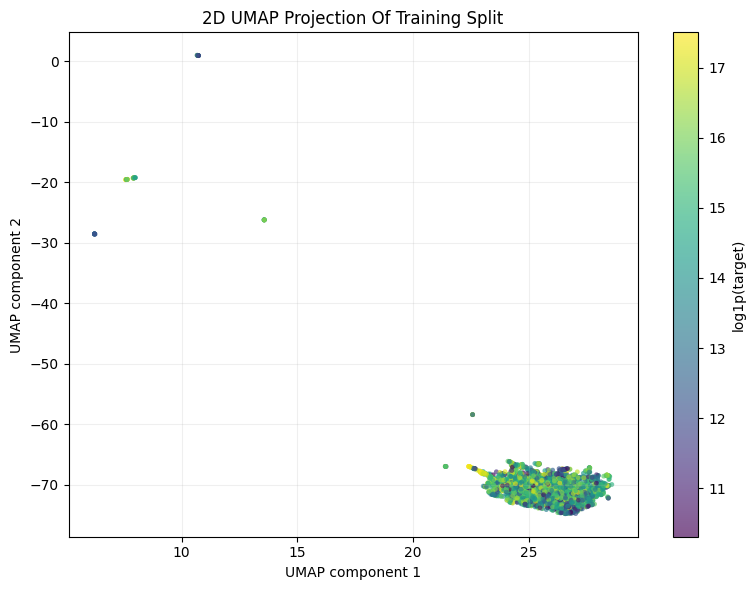

base_features_kept       2482
base_features_removed    2249
final_features              2
Name: value, dtype: int64

In [7]:
# Use two UMAP components only for a visual diagnostic scatter plot.
UMAP_PLOT_COMPONENTS = 2

# Fit the same leakage-safe pipeline on the train split and transform the test split.
# The plot below uses the train embedding because train rows have known targets and were used to fit UMAP.
X_train_umap_2d, X_test_umap_2d, umap_2d_diagnostics = build_umap_features(
    X_fit=X_train_raw,
    X_transform=X_test_raw,
    n_components=UMAP_PLOT_COMPONENTS,
)

# Color by log1p(target), not raw target, because the raw target is very skewed.
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    X_train_umap_2d["umap_001"],
    X_train_umap_2d["umap_002"],
    c=y_train_log,
    cmap="viridis",
    s=12,
    alpha=0.65,
    linewidths=0,
)

ax.set_title("2D UMAP Projection Of Training Split")
ax.set_xlabel("UMAP component 1")
ax.set_ylabel("UMAP component 2")
ax.grid(alpha=0.2)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("log1p(target)")

plt.tight_layout()
plt.show()

# Display preprocessing diagnostics so the visualization is easy to audit.
pd.Series(umap_2d_diagnostics, name="value")

## Cross-Validation

Lower `cv_rmsle_mean` is better. Each fold refits sparse filtering, scaler, UMAP, and LightGBM from scratch.

In [8]:
def evaluate_cv(n_components: int) -> dict[str, float | int]:
    fold_scores = []
    base_features_kept = []

    for fold_train_idx, fold_valid_idx in cv.split(X_train_raw, y_train_log):
        X_fold_train_raw = X_train_raw.iloc[fold_train_idx]
        X_fold_valid_raw = X_train_raw.iloc[fold_valid_idx]
        y_fold_train_log = y_train_log.iloc[fold_train_idx]
        y_fold_valid_log = y_train_log.iloc[fold_valid_idx]

        X_fold_train, X_fold_valid, diagnostics = build_umap_features(
            X_fit=X_fold_train_raw,
            X_transform=X_fold_valid_raw,
            n_components=n_components,
        )

        model = build_lgbm_regressor(LGBM_PARAMS)
        model.fit(X_fold_train, y_fold_train_log)
        y_fold_pred_log = model.predict(X_fold_valid)

        # RMSE in log-target space is the same objective as RMSLE after expm1.
        fold_rmsle = root_mean_squared_error(y_fold_valid_log, y_fold_pred_log)
        fold_scores.append(fold_rmsle)
        base_features_kept.append(diagnostics["base_features_kept"])

    return {
        "n_components": n_components,
        "cv_rmsle_mean": float(np.mean(fold_scores)),
        "cv_rmsle_std": float(np.std(fold_scores)),
        "base_features_kept_mean": float(np.mean(base_features_kept)),
    }

In [9]:
# Collect CV results for every candidate number of UMAP components.
results = []

for n_components in UMAP_COMPONENTS:
    results.append(evaluate_cv(n_components=n_components))

# Sort by mean CV RMSLE; the first row is the best candidate.
results_df = pd.DataFrame(results).sort_values("cv_rmsle_mean")
results_df

/Users/ayeustsihneyeu/ml_/santander/.santander/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ayeustsihneyeu/ml_/santander/.santander/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ayeustsihneyeu/ml_/santander/.santander/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ayeustsihneyeu/ml_/santander/.santander/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ayeustsihneyeu/ml_/santander/.santander/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism

,n_components,cv_rmsle_mean,cv_rmsle_std,base_features_kept_mean
0,10,1.697171,0.030228,2498.2
1,25,1.701602,0.047450,2498.2
2,50,1.725919,0.041577,2498.2


In [10]:
# Display the same table with compact metric formatting for easier notebook reading.
results_df.style.format(
    {
        "cv_rmsle_mean": "{:.4f}",
        "cv_rmsle_std": "{:.4f}",
        "base_features_kept_mean": "{:,.0f}",
    }
).hide(axis="index")

n_components,cv_rmsle_mean,cv_rmsle_std,base_features_kept_mean
10,1.6972,0.0302,"2,498"
25,1.7016,0.0475,"2,498"
50,1.7259,0.0416,"2,498"


## Final Holdout Evaluation

After CV selects the component count, fit sparse filtering, scaler, UMAP, and LightGBM on the full training split, then evaluate once on the held-out test split.

In [11]:
best_row = results_df.iloc[0]
best_n_components = int(best_row["n_components"])
best_n_components

10

In [12]:
X_train_final, X_test_final, final_diagnostics = build_umap_features(
    X_fit=X_train_raw,
    X_transform=X_test_raw,
    n_components=best_n_components,
)

final_model = build_lgbm_regressor(LGBM_PARAMS)
final_model.fit(X_train_final, y_train_log)

# Predict both train and test to inspect overfitting.
y_train_pred_log = final_model.predict(X_train_final)
y_test_pred_log = final_model.predict(X_test_final)

# Transform back to the original target scale.
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)

# Clipping prevents invalid negative predictions for RMSLE.
y_train_pred = np.clip(y_train_pred, 0, None)
y_test_pred = np.clip(y_test_pred, 0, None)

(X_train_final.shape, X_test_final.shape, final_diagnostics)

/Users/ayeustsihneyeu/ml_/santander/.santander/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


((2987, 10),
 (1472, 10),
 {'base_features_kept': 2482,
  'base_features_removed': 2249,
  'final_features': 10})

In [13]:
# RMSLE is the primary metric and matches the log-target training objective.
train_rmsle = root_mean_squared_log_error(y_train_raw, y_train_pred)
test_rmsle = root_mean_squared_log_error(y_test_raw, y_test_pred)
# RMSE and MAE are reported on the original target scale for business interpretability.
train_rmse = root_mean_squared_error(y_train_raw, y_train_pred)
test_rmse = root_mean_squared_error(y_test_raw, y_test_pred)
train_mae = mean_absolute_error(y_train_raw, y_train_pred)
test_mae = mean_absolute_error(y_test_raw, y_test_pred)
# R2 gives a familiar variance-explained view, but RMSLE remains the decision metric.
train_r2 = r2_score(y_train_raw, y_train_pred)
test_r2 = r2_score(y_test_raw, y_test_pred)

metrics = pd.DataFrame(
    {
        "metric": [
            "sparsity_threshold",
            "base_features_kept",
            "base_features_removed",
            "best_n_components",
            "final_features",
            "cv_rmsle_mean",
            "cv_rmsle_std",
            "train_rmsle",
            "test_rmsle",
            "rmsle_gap_test_minus_train",
            "train_rmse",
            "test_rmse",
            "rmse_gap_test_minus_train",
            "train_mae",
            "test_mae",
            "train_r2",
            "test_r2",
        ],
        "value": [
            SPARSITY_THRESHOLD,
            final_diagnostics["base_features_kept"],
            final_diagnostics["base_features_removed"],
            best_n_components,
            X_train_final.shape[1],
            best_row["cv_rmsle_mean"],
            best_row["cv_rmsle_std"],
            train_rmsle,
            test_rmsle,
            test_rmsle - train_rmsle,
            train_rmse,
            test_rmse,
            test_rmse - train_rmse,
            train_mae,
            test_mae,
            train_r2,
            test_r2,
        ],
    }
)

# Reuse the project formatter so large currency-like errors and small metrics are readable.
metrics.style.format({"value": format_metric_value}).hide(axis="index")

metric,value
sparsity_threshold,0.9875
base_features_kept,"2,482"
base_features_removed,"2,249"
best_n_components,10
final_features,10
cv_rmsle_mean,1.6972
cv_rmsle_std,0.0302
train_rmsle,1.4034
test_rmsle,1.6616
rmsle_gap_test_minus_train,0.2582


## Summary

The summary dictionary makes it easy to copy the result into final reports after running the notebook.

In [14]:
# Machine-readable summary of the experiment. Use this when updating final reports.
summary = {
    "target_transform": "log1p",
    "primary_metric": "rmsle",
    "model": "LGBMRegressor",
    "dimensionality_reduction": "UMAP",
    "umap_mode": UMAP_MODE,
    "umap_components": UMAP_COMPONENTS,
    "umap_params": UMAP_PARAMS,
    "cv_folds": CV,
    "test_size": TEST_SIZE,
    "seed": SEED,
    "sparsity_threshold": SPARSITY_THRESHOLD,
    "model_params": LGBM_PARAMS,
    "best_n_components": best_n_components,
    "base_features_kept": final_diagnostics["base_features_kept"],
    "base_features_removed": final_diagnostics["base_features_removed"],
    "final_features": X_train_final.shape[1],
    "cv_rmsle_mean": float(best_row["cv_rmsle_mean"]),
    "cv_rmsle_std": float(best_row["cv_rmsle_std"]),
    "train_rmsle": float(train_rmsle),
    "test_rmsle": float(test_rmsle),
    "rmsle_gap_test_minus_train": float(test_rmsle - train_rmsle),
    "train_rmse": float(train_rmse),
    "test_rmse": float(test_rmse),
    "rmse_gap_test_minus_train": float(test_rmse - train_rmse),
    "train_mae": float(train_mae),
    "test_mae": float(test_mae),
    "train_r2": float(train_r2),
    "test_r2": float(test_r2),
}

summary

{'target_transform': 'log1p',
 'primary_metric': 'rmsle',
 'model': 'LGBMRegressor',
 'dimensionality_reduction': 'UMAP',
 'umap_mode': 'umap_only_after_sparse_filter',
 'umap_components': [10, 25, 50],
 'umap_params': {'n_neighbors': 15,
  'min_dist': 0.1,
  'metric': 'euclidean',
  'low_memory': True,
  'random_state': 42},
 'cv_folds': 5,
 'test_size': 0.33,
 'seed': 42,
 'sparsity_threshold': 0.9875,
 'model_params': {'n_estimators': 700,
  'learning_rate': 0.01,
  'num_leaves': 31,
  'max_depth': 6,
  'min_child_samples': 40,
  'subsample': 0.75,
  'subsample_freq': 1,
  'colsample_bytree': 0.75,
  'reg_alpha': 0.1,
  'reg_lambda': 5.0,
  'min_split_gain': 0.05},
 'best_n_components': 10,
 'base_features_kept': 2482,
 'base_features_removed': 2249,
 'final_features': 10,
 'cv_rmsle_mean': 1.6971706215789346,
 'cv_rmsle_std': 0.030227884127561503,
 'train_rmsle': 1.4033876642769418,
 'test_rmsle': 1.6615673485263474,
 'rmsle_gap_test_minus_train': 0.2581796842494055,
 'train_rmse':

## How To Read The Result

- Compare `cv_rmsle_mean` against notebooks `10` and `11` to see whether non-linear UMAP compression works better than PCA or TruncatedSVD.
- Compare against notebooks `08` and `09` to check whether UMAP-only features can compete with the original sparse-filtered row-wise feature setup.
- UMAP is stochastic and can be slower than PCA/SVD; rerun with the same seed before making final conclusions.
- A large positive `rmsle_gap_test_minus_train` means the model fits train much better than unseen test data.
- Treat `test_rmsle` as a sanity check, not as the optimization target.

# 12 UMAP LGBM Report

Run the notebook first, then fill this report from the `summary` dictionary and the CV result table.

## Goal

The goal of this notebook is to test whether non-linear `UMAP` components can replace the sparse anonymous feature set for LightGBM regression.

## What Was Done

- Loaded `data/processed_data.csv`.
- Split the data into train and test parts with `test_size=0.33` and seed `42`.
- Used `log1p(target)` and optimized log-space RMSE, equivalent to RMSLE for this target transform.
- Fitted sparse filtering inside each CV fold with threshold `0.9875`.
- Scaled features with `StandardScaler(with_mean=False)` to preserve sparse structure.
- Converted the feature matrix to CSR sparse format.
- Fitted `UMAP` inside each CV fold to avoid leakage.
- Tested UMAP component counts: `10`, `25`, `50`.
- Trained a fixed conservative `LGBMRegressor` on UMAP components only.

## Result

After running the notebook, copy the CV table and final metrics here.

## Expected Interpretation

UMAP may help if local non-linear neighborhoods contain target-relevant structure that PCA/SVD miss. If CV or test RMSLE remains worse than notebooks `08` and `09`, then UMAP-only compression should be treated as a negative experiment. In that case, a better follow-up would be adding UMAP components to the original sparse-filtered row-wise features rather than replacing those features completely.